In [7]:
import geopandas as gpd
import osmnx as ox
import networkx as nx
from shapely.geometry import Point, MultiPoint, Polygon
from shapely import union_all

In [ ]:
gdf_adelaide = gpd.read_file("../data/processed/sa1_adelaide.geojson")

adelaide_boundary_4326 = gdf_adelaide.to_crs(epsg=4326).union_all()

print("Downloading walkable network from OpenStreetMap, please wait")
G_walk = ox.graph_from_polygon(adelaide_boundary_4326, network_type="walk")

G_proj = ox.project_graph(G_walk, to_crs="EPSG:7854")

print(f"Network loaded, total nodes: {len(G_proj.nodes)}, total edges: {len(G_proj.edges)}")

/tmp/ipykernel_21088/449772623.py:3: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  adelaide_boundary_4326 = gdf_adelaide.to_crs(epsg=4326).unary_union


Network loaded, total nodes: 210917, total edges: 606774


In [9]:
#load stops
gdf_stops = gpd.read_file("../data/processed/stops_adelaide.geojson")
high_freq_stops = gdf_stops[gdf_stops["is_high_frequency"] == True].copy()

#co-ordinates
stop_x = high_freq_stops.geometry.x.values
stop_y = high_freq_stops.geometry.y.values

#graph node IDs
nearest_nodes = ox.distance.nearest_nodes(G_proj, X=stop_x, Y=stop_y)
high_freq_stops["nearest_node"] = nearest_nodes

In [15]:
def make_isochrone_polygons(graph, stop_nodes, distances=[400,800,1200]):
    isochrone_polys = {dist: [] for dist in distances}

    for node in stop_nodes:
        for dist in distances:
            subgraph = nx.ego_graph(graph, node, radius=dist, distance="length")
            node_points = [
                Point(graph.nodes[n]["x"], graph.nodes[n]["y"])
                for n in subgraph.nodes
            ]

            if len(node_points) >= 3:
                poly = MultiPoint(node_points).convex_hull.buffer(20)
            elif len(node_points) > 0:
                poly = MultiPoint(node_points).buffer(30)
            else:
                continue

            isochrone_polys[dist].append(poly)
    
    dissolved_layers = {}
    for dist, polys in isochrone_polys.items():
        unified_geom = gpd.GeoSeries(polys).union_all()
        gdf_catchment = gpd.GeoDataFrame(
            geometry=[unified_geom],
            crs=graph.graph["crs"]
        )
        dissolved_layers[dist] = gdf_catchment
    return dissolved_layers

catchments = make_isochrone_polygons(
    G_proj, 
    high_freq_stops["nearest_node"].unique(), 
    distances=[400, 800, 1200]
)

gdf_walk_400m = catchments[400]
gdf_walk_800m = catchments[800]
gdf_walk_1200m = catchments[1200]

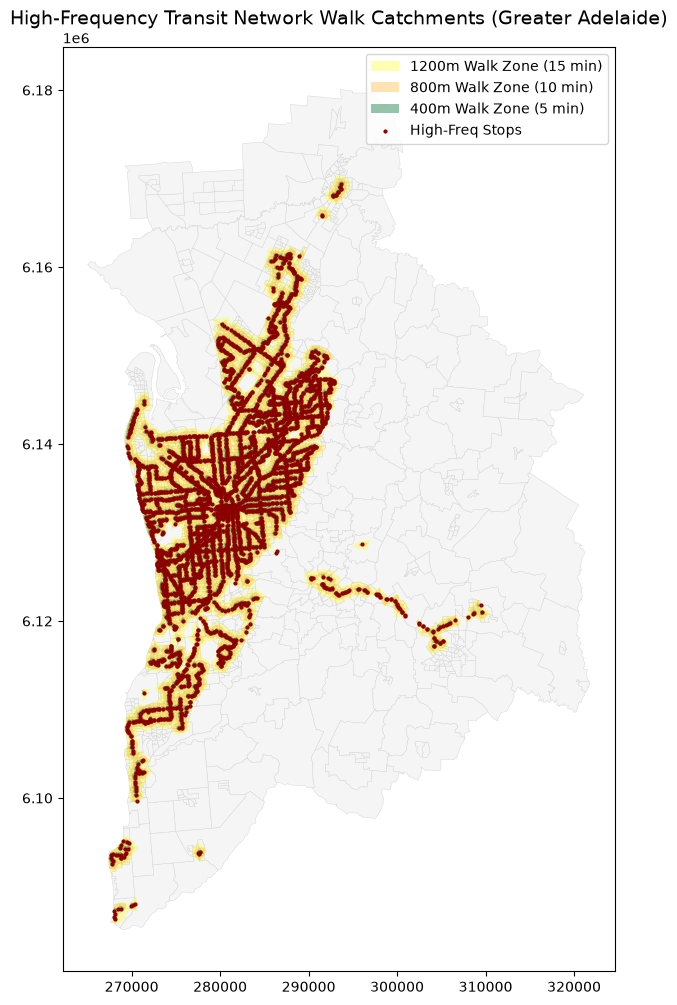

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

#base SA1 map
gdf_adelaide.plot(ax=ax, color="whitesmoke", edgecolor="lightgray", linewidth=0.3)

#1200m catchment
gdf_walk_1200m.plot(ax=ax, color="yellow", alpha=0.3, label="1200m Walk Zone (15 min)")

#800m catchment
gdf_walk_800m.plot(ax=ax, color="orange", alpha=0.3, label="800m Walk Zone (10 min)")

#400m catchment
gdf_walk_400m.plot(ax=ax, color="seagreen", alpha=0.5, label="400m Walk Zone (5 min)")

high_freq_stops.plot(ax=ax, color="darkred", markersize=4, label="High-Freq Stops")

plt.title("High-Frequency Transit Network Walk Catchments (Greater Adelaide)", fontsize=14)
plt.legend(loc="upper right")
plt.show()

In [20]:
gdf_walk_400m.to_file("../data/processed/walk_catchment_400m.geojson", driver="GeoJSON")
gdf_walk_800m.to_file("../data/processed/walk_catchment_800m.geojson", driver="GeoJSON")
gdf_walk_1200m.to_file("../data/processed/walk_catchment_1200m.geojson", driver="GeoJSON")